In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import scanpy as sc
import squidpy as sq

from pathlib import Path

import sys
sys.path.append('/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/scripts')
import coda
import readwrite
cfg = readwrite.config()


/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/norkin_39/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
import joblib
joblib.load("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/organoid_masks_official_standardized.pkl")

<function joblib.numpy_pickle.load(filename, mmap_mode=None, ensure_native_byte_order='auto')>

# 0. Params and Settings

In [2]:
# ["run_1"]="1HVQ 1CNN 077I 1GAA 1J25 131N OWJ3 14PT"
# ["run_2"]="169V 1BI7 1CI5 1FMS 12NM OLR9 1GVB 1GNS"

PATIENT_ID = "1CNN"
ORGANOID_CELL_MAPPING_PATH = "/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/ORGANOID_IDs_Xenium_norkin.csv"
ALIGNMENTS_ROOT_PATH = f"/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/results/alignments/{PATIENT_ID}"
ORGANOID_COUNT_THRESHOLD = 20
SCALE_FACTOR = 1 / 0.2125

# 1. Organoid Generation
## 1a. Organoid - Cell Mappings
Reads in a dataframe that maps between cells and organoids via the proseg segmentation. 


In [3]:
organoid_cell_mapping = pd.read_csv(ORGANOID_CELL_MAPPING_PATH)
organoid_cell_mapping = organoid_cell_mapping[organoid_cell_mapping['Organoid_ID'] > 0]
print("sample cell id: ", organoid_cell_mapping.iloc[0]['Cell_ID'])
organoid_cell_mapping.head()

sample cell id:  proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_output-XETG00059__0021741__O3F0__20250319__172035_proseg-0


,Cell_ID,Organoid_ID
0,proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_out...,1
1,proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_out...,2
2,proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_out...,3
3,proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_out...,4
4,proseg_expected_CRC_PDO_hImmune_v1_mm_03FO_out...,5


In [4]:
relevant_organoid_cell_mapping = organoid_cell_mapping[organoid_cell_mapping['Cell_ID'].str.contains(f"_{PATIENT_ID}_")]
print("cell count: ", relevant_organoid_cell_mapping.shape[0])
relevant_organoid_cell_mapping.head()


cell count:  5223


,Cell_ID,Organoid_ID
607912,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
607913,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2396
607914,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2397
607915,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
607916,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2398


## 1b. Spatialdata Cell Geometry
Read in the spatialdata object via readwrite to get the cell geometry. 

In [5]:
# input params
correction_method = 'raw'
segmentation = 'proseg_expected'
condition = 'CRC_PDO'
panel = 'all'

xenium_dir = Path(cfg['xenium_processed_dir'])
xenium_count_correction_dir = Path(cfg['xenium_count_correction_dir'])
xenium_std_seurat_analysis_dir = Path(cfg['xenium_std_seurat_analysis_dir'])
xenium_cell_type_annotation_dir = Path(cfg['xenium_cell_type_annotation_dir'])
results_dir = Path(cfg['results_dir'])

xenium_levels = ['segmentation','condition','panel','donor','sample']
normalisation = 'lognorm'
reference = 'GEO_GSE236581' # 'GEO_GSE178341'
method = 'rctd_class_aware'
level = 'Level1'


# fixed params
BATCH_KEY = 'dataset_id'
SPATIAL_KEY = 'spatial'
N_CLUSTERS_RANGE = (5,19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001
OUTPUT_LABELS = results_dir/'xenium/cellcharter/labels.parquet'
OUTPUT_SCVI_MODEL = results_dir/'xenium/cellcharter/scvi_model'
OUTPUT_CELLCHARTER_MODELS = results_dir/'xenium/cellcharter/cellcharter_models'
OUTPUT_PLOT = results_dir/'xenium/cellcharter/autok_stability.png'



# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=[condition] if condition != 'all' else None,
    panels_filter=[panel] if panel != 'all' else None
)


# set transcripts=True to load individual transcripts positions)
if correction_method != 'raw':
    ads = readwrite.read_count_correction_samples(xenium_paths,[correction_method])
else:
    ads = {}
    ads['raw'] = readwrite.read_xenium_samples(
        xenium_paths['raw'],  
        anndata=False,
        cells_boundaries=True, 
        pool_mode="thread",
        max_workers=6
    )

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/norkin_39/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/norkin_39/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/norkin_39/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/workflow/scripts/readwrite.py:352: UserWarning: 
                Couldn't load xenium specs file with pixel size. 
                Not applying scale transformations to shapes.
               

Could not find annotation file for ('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '18samples', 'output-XETG00059__0033132__PDO_18samples__20250821__124603'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO/hImmune_v1_dapi/18samples/output-XETG00059__0033132__PDO_18samples__20250821__124603/lognorm/reference_based/GEO_GSE236581/rctd_class_aware/Level1/single_cell/labels.parquet


/work/PRTNR/CHUV/DIR/rgottar1/spatial/conda_envs/norkin_39/lib/python3.9/site-packages/spatialdata/_core/_elements.py:116: UserWarning: Key `table` already exists. Overwriting it in-memory.
  self._check_key(key, self.keys(), self._shared_keys)


In [14]:
for key in ads['raw'].keys():
    print(key)

('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1CNN', 'output-XETG00059__0003381__1CNN__20250505__170803')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1BI7', 'output-XETG00059__0003881__1BI7__20250505__170804')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', 'OWJ3', 'output-XETG00059__0003381__OWJ3__20250505__170803')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1HVQ', 'output-XETG00059__0003381__1HVQ__20250505__170803')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1GNS', 'output-XETG00059__0003881__1GNS__20250505__170804')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1GVB', 'output-XETG00059__0003881__1GVB__20250505__170804')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '1J25', 'output-XETG00059__0003381__1J25__20250505__170803')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '131N', 'output-XETG00059__0003381__131N__20250505__170803')
('proseg_expected', 'CRC_PDO', 'hImmune_v1_dapi', '12NM', 'output-XETG00059__0003881__12NM__20250505__170804')
(

In [15]:
proseg_key = ('proseg_expected',
  'CRC_PDO',
  'hImmune_v1_dapi',
  PATIENT_ID,
  f'output-XETG00059__0003381__{PATIENT_ID}__20250505__170803')
proseg_key_str = "_".join(proseg_key) + "_proseg"

geo_df = ads['raw'][proseg_key].shapes['cells_boundaries']
print("cell count: ", geo_df.shape[0])   
geo_df.head()

cell count:  6160


,cell_id,geometry
0,0,"MULTIPOLYGON (((2160 214, 2160 210, 2161 210, ..."
1,1,"MULTIPOLYGON (((2945 904, 2945 903, 2946 903, ..."
2,2,"MULTIPOLYGON (((3041 1644, 3041 1643, 3047 164..."
3,3,"MULTIPOLYGON (((2257 386, 2257 385, 2258 385, ..."
4,4,"MULTIPOLYGON (((3137 1141, 3137 1142, 3136 114..."


In [16]:
relevant_organoid_cell_mapping

,Cell_ID,Organoid_ID
607912,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
607913,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2396
607914,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2397
607915,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
607916,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2398
...,...,...
613168,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2398
613169,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2399
613170,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2399
613171,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2398


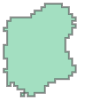

In [10]:
geo_df.iloc[0].geometry

In [17]:
geo_df['full_cell_id'] = geo_df['cell_id'].apply(
    lambda x: f"{proseg_key_str}-{x}"
)
print(geo_df['full_cell_id'].iloc[0])
print(organoid_cell_mapping[organoid_cell_mapping['Cell_ID'].str.contains("_dapi_")]["Cell_ID"].iloc[0])

proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_output-XETG00059__0003381__1CNN__20250505__170803_proseg-0
proseg_expected_CRC_PDO_hImmune_v1_dapi_077I_output-XETG00059__0003381__077I__20250505__170803_proseg-0


In [18]:
joined_df = geo_df.merge(relevant_organoid_cell_mapping, 
                        left_on='full_cell_id', 
                        right_on='Cell_ID', 
                        how='inner')

# Get organoid IDs with at least 20 cells
organoid_counts = joined_df['Organoid_ID'].value_counts()
valid_organoids = organoid_counts[organoid_counts >= ORGANOID_COUNT_THRESHOLD].index

# Filter the DataFrame
joined_df = joined_df[joined_df['Organoid_ID'].isin(valid_organoids)]

print("joined cell count: ", joined_df.shape[0])
joined_df.head()

joined cell count:  5175


,cell_id,geometry,full_cell_id,Cell_ID,Organoid_ID
0,0,"MULTIPOLYGON (((2160 214, 2160 210, 2161 210, ...",proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
1,1,"MULTIPOLYGON (((2945 904, 2945 903, 2946 903, ...",proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2396
2,2,"MULTIPOLYGON (((3041 1644, 3041 1643, 3047 164...",proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2397
3,3,"MULTIPOLYGON (((2257 386, 2257 385, 2258 385, ...",proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2395
4,4,"MULTIPOLYGON (((3137 1141, 3137 1142, 3136 114...",proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,proseg_expected_CRC_PDO_hImmune_v1_dapi_1CNN_o...,2398


## Visualizing the organoids

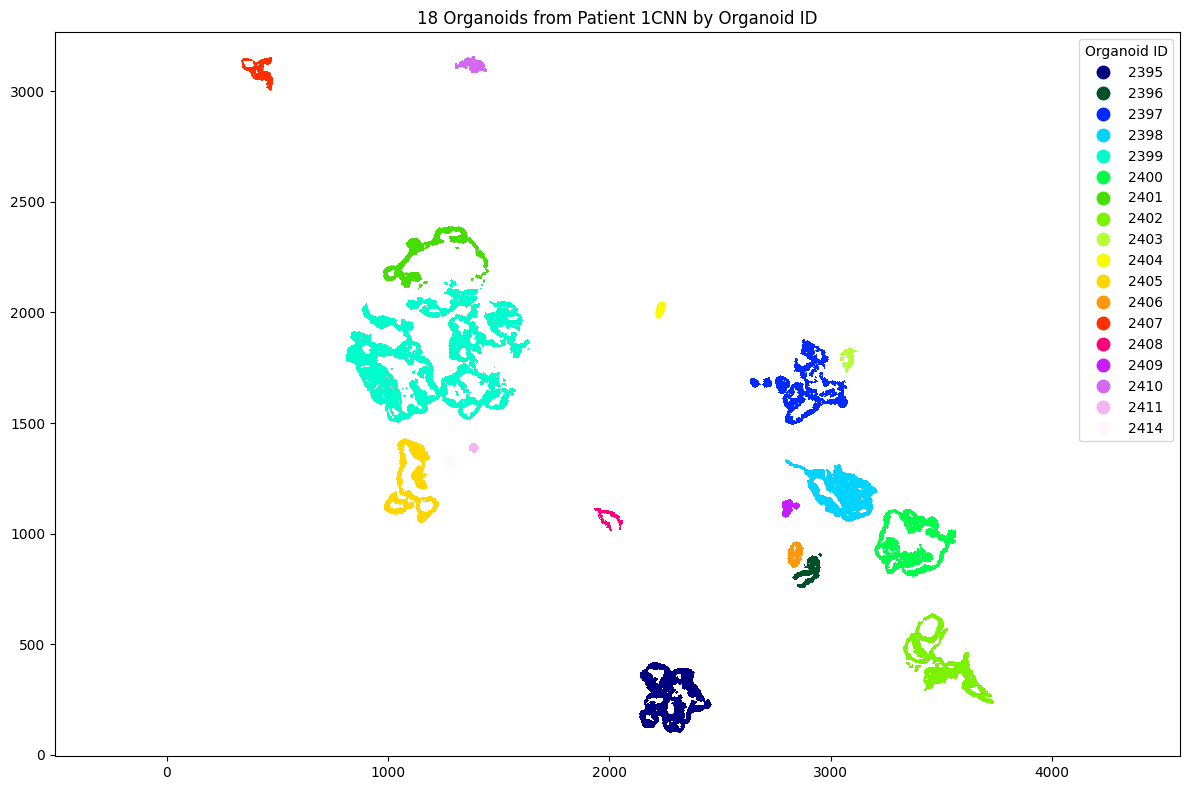

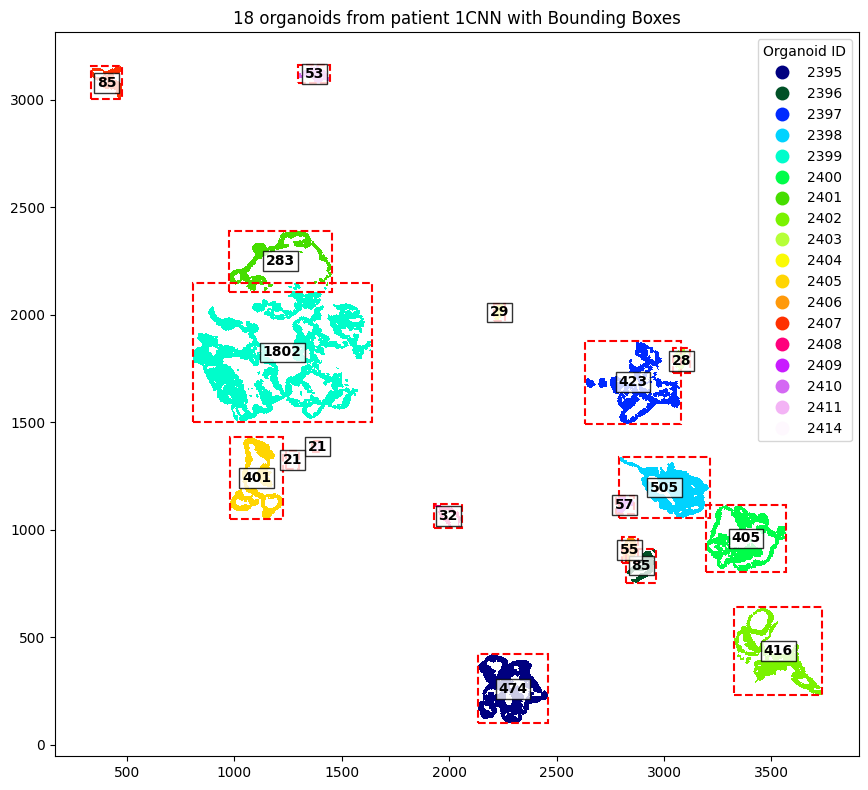

In [19]:
# Plot 1: Categorical organoid plot
joined_df.plot(
    column='Organoid_ID', 
    categorical=True,
    legend=True,
    cmap='gist_ncar',
    linewidth=0.5,
    aspect=1,
    figsize=(12, 8),
    legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1, 1), 'title': 'Organoid ID'}
)

num_organoids = len(joined_df['Organoid_ID'].unique())
plt.title(f'{num_organoids} Organoids from Patient {PATIENT_ID} by Organoid ID')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Plot 2: With bounding boxes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the organoids
joined_df.plot(
    ax=ax,
    aspect=1,
    column='Organoid_ID', 
    categorical=True,
    legend=True,
    cmap='gist_ncar',
    linewidth=0.5,
    legend_kwds={'loc': 'upper right', 'bbox_to_anchor': (1, 1), 'title': 'Organoid ID'}
)

# Add bounding boxes and labels for each organoid
for organoid_id, group in joined_df.groupby('Organoid_ID'):
    # Get bounding box
    minx, miny, maxx, maxy = group.total_bounds
    
    # Draw bounding box
    rect = plt.Rectangle(
        (minx, miny), maxx-minx, maxy-miny,
        fill=False, 
        edgecolor='red', 
        linewidth=1.5, 
        linestyle='--'
    )
    ax.add_patch(rect)
    
    # Add cell count label at center
    center_x, center_y = (minx + maxx) / 2, (miny + maxy) / 2
    ax.text(
        center_x, center_y, 
        f'{len(group)}',
        ha='center', 
        va='center', 
        fontweight='bold',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', pad=2)
    )
ax.set_title(f'{num_organoids} organoids from patient {PATIENT_ID} with Bounding Boxes')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 1c. Polygons for the Organoids and update to the NorkinOrganoid Dataset

In [14]:
def generate_organoid_masks_with_square_bboxes(geo_df, scale=True, output_size=(224, 224), padding_ratio=0.1, outline_thickness=1, max_pixel_side_length=None):
    """
    Generate masks with both original and square bounding boxes.
    
    Returns:
        Tuple of (organoid_masks, organoid_bboxes, square_bboxes) where:
        - organoid_masks: Dictionary mapping organoid IDs to mask numpy arrays
        - organoid_bboxes: Dictionary mapping organoid IDs to original bounding boxes with padding
        - square_bboxes: Dictionary mapping organoid IDs to square bounding boxes that match the mask content
    """
    import numpy as np
    from skimage.draw import line_aa
    import geopandas as gpd
    
    # Get unique organoid IDs
    organoid_ids = geo_df['Organoid_ID'].unique()
    num_organoids = len(organoid_ids)
    print(f"Processing {num_organoids} organoids")
    
    # Dictionaries to store masks and bounding boxes
    organoid_masks = {}
    organoid_bboxes = {}  # Original bboxes with proportional padding
    square_bboxes = {}    # Square bboxes that match mask content
    
    # Process each organoid individually
    for organoid_id in organoid_ids:
        # Filter for this specific organoid using GeoPandas
        organoid_gdf = geo_df[geo_df['Organoid_ID'] == organoid_id].copy()
        
        # Skip if no geometries
        if len(organoid_gdf) == 0:
            organoid_masks[organoid_id] = np.zeros(output_size[::-1], dtype=np.uint8)
            organoid_bboxes[organoid_id] = (0, 0, 0, 0)
            square_bboxes[organoid_id] = (0, 0, 0, 0)
            continue
        
        # Get bounding box for THIS organoid using GeoPandas total_bounds
        min_x, min_y, max_x, max_y = organoid_gdf.total_bounds
        
        # Calculate content dimensions
        content_width = max_x - min_x
        content_height = max_y - min_y
        
        # Handle zero dimensions
        if content_width == 0 or content_height == 0:
            organoid_masks[organoid_id] = np.zeros(output_size[::-1], dtype=np.uint8)
            padding = output_size[0] * padding_ratio  # Use output size for zero-dim case
            organoid_bboxes[organoid_id] = (min_x-padding, min_y-padding, max_x+padding, max_y+padding)
            square_bboxes[organoid_id] = (min_x-padding, min_y-padding, max_x+padding, max_y+padding)
            continue
        
        # Calculate scaling and offset (same as before)
        if not scale:
            final_scale = 1.0
            padding_x = content_width * padding_ratio
            padding_y = content_height * padding_ratio
            
            # Original bounding box with proportional padding
            bbox_with_padding = (
                min_x - padding_x,
                min_y - padding_y,
                max_x + padding_x,
                max_y + padding_y
            )
            
            effective_width = content_width + 2 * padding_x
            effective_height = content_height + 2 * padding_y
            final_offset_x = (output_size[0] - effective_width * final_scale) / 2 - (min_x - padding_x) * final_scale
            final_offset_y = (output_size[1] - effective_height * final_scale) / 2 - (min_y - padding_y) * final_scale
            
        elif max_pixel_side_length is not None:
            scale_factor = max(output_size) / max_pixel_side_length
            final_scale = scale_factor
            
            padding_x = content_width * padding_ratio
            padding_y = content_height * padding_ratio
            
            bbox_with_padding = (
                min_x - padding_x,
                min_y - padding_y,
                max_x + padding_x,
                max_y + padding_y
            )
            
            scaled_width = content_width * final_scale
            scaled_height = content_height * final_scale
            final_offset_x = (output_size[0] - scaled_width) / 2 - min_x * final_scale
            final_offset_y = (output_size[1] - scaled_height) / 2 - min_y * final_scale
            
        else:
            width_scale = (output_size[0] * (1 - 2*padding_ratio)) / content_width
            height_scale = (output_size[1] * (1 - 2*padding_ratio)) / content_height
            final_scale = min(width_scale, height_scale)
            
            padding_x = (content_width * padding_ratio) / (1 - 2*padding_ratio)
            padding_y = (content_height * padding_ratio) / (1 - 2*padding_ratio)
            
            bbox_with_padding = (
                min_x - padding_x,
                min_y - padding_y,
                max_x + padding_x,
                max_y + padding_y
            )
            
            final_offset_x = (output_size[0] - content_width * final_scale) / 2 - min_x * final_scale
            final_offset_y = (output_size[1] - content_height * final_scale) / 2 - min_y * final_scale
        
        # Store the original bounding box with proportional padding
        organoid_bboxes[organoid_id] = bbox_with_padding
        
        # Calculate SQUARE bounding box that matches the mask content
        # The mask content is centered and scaled to fit the output_size with padding
        center_x = (min_x + max_x) / 2
        center_y = (min_y + max_y) / 2
        
        # Calculate the actual content area that appears in the square mask
        if not scale:
            # For scale=False, we use the larger dimension plus padding
            larger_dim = max(content_width, content_height)
            square_half_size = (larger_dim * (1 + 2 * padding_ratio)) / 2
        elif max_pixel_side_length is not None:
            # Scale to fit max_pixel_side_length
            larger_dim = max(content_width, content_height)
            square_half_size = (larger_dim * (1 + 2 * padding_ratio)) / 2
        else:
            # Scale to fit output_size with padding
            # The effective content area in original coordinates
            effective_pixel_width = output_size[0] * (1 - 2 * padding_ratio)
            effective_pixel_height = output_size[1] * (1 - 2 * padding_ratio)
            
            # Convert back to original coordinates using the actual scale used
            effective_width = effective_pixel_width / final_scale
            effective_height = effective_pixel_height / final_scale
            
            # Use the larger dimension to ensure squareness
            larger_effective_dim = max(effective_width, effective_height)
            square_half_size = larger_effective_dim / 2
        
        square_bbox = (
            center_x - square_half_size,
            center_y - square_half_size,
            center_x + square_half_size,
            center_y + square_half_size
        )
        
        # Store the square bounding box
        square_bboxes[organoid_id] = square_bbox
        
        # Create empty mask (same as before)
        mask = np.zeros(output_size[::-1], dtype=np.uint8)
        
        # Function to draw thick line
        def draw_thick_line(mask, r0, c0, r1, c1, thickness):
            if thickness == 1:
                rr, cc, val = line_aa(r0, c0, r1, c1)
                mask[rr, cc] = np.maximum(mask[rr, cc], (val * 255).astype(np.uint8))
            else:
                for t in range(-thickness//2, thickness//2 + 1):
                    rr, cc, val = line_aa(r0 + t, c0 + t, r1 + t, c1 + t)
                    valid = (rr >= 0) & (rr < mask.shape[0]) & (cc >= 0) & (cc < mask.shape[1])
                    mask[rr[valid], cc[valid]] = np.maximum(mask[rr[valid], cc[valid]], 
                                                           (val[valid] * 255).astype(np.uint8))
        
        # Process each geometry in the organoid (same as before)
        for idx, row in organoid_gdf.iterrows():
            geom = row['geometry']
            
            if geom.geom_type == 'Polygon':
                exterior_coords = list(geom.exterior.coords)
                for i in range(len(exterior_coords)):
                    x1, y1 = exterior_coords[i]
                    x2, y2 = exterior_coords[(i + 1) % len(exterior_coords)]
                    
                    x1_scaled = int(x1 * final_scale + final_offset_x)
                    y1_scaled = int(y1 * final_scale + final_offset_y)
                    x2_scaled = int(x2 * final_scale + final_offset_x)
                    y2_scaled = int(y2 * final_scale + final_offset_y)
                    
                    x1_scaled = np.clip(x1_scaled, 0, output_size[0] - 1)
                    y1_scaled = np.clip(y1_scaled, 0, output_size[1] - 1)
                    x2_scaled = np.clip(x2_scaled, 0, output_size[0] - 1)
                    y2_scaled = np.clip(y2_scaled, 0, output_size[1] - 1)
                    
                    draw_thick_line(mask, y1_scaled, x1_scaled, y2_scaled, x2_scaled, outline_thickness)
                
                for interior in geom.interiors:
                    interior_coords = list(interior.coords)
                    for i in range(len(interior_coords)):
                        x1, y1 = interior_coords[i]
                        x2, y2 = interior_coords[(i + 1) % len(interior_coords)]
                        
                        x1_scaled = int(x1 * final_scale + final_offset_x)
                        y1_scaled = int(y1 * final_scale + final_offset_y)
                        x2_scaled = int(x2 * final_scale + final_offset_x)
                        y2_scaled = int(y2 * final_scale + final_offset_y)
                        
                        x1_scaled = np.clip(x1_scaled, 0, output_size[0] - 1)
                        y1_scaled = np.clip(y1_scaled, 0, output_size[1] - 1)
                        x2_scaled = np.clip(x2_scaled, 0, output_size[0] - 1)
                        y2_scaled = np.clip(y2_scaled, 0, output_size[1] - 1)
                        
                        draw_thick_line(mask, y1_scaled, x1_scaled, y2_scaled, x2_scaled, outline_thickness)
            
            elif geom.geom_type == 'MultiPolygon':
                for poly in geom.geoms:
                    exterior_coords = list(poly.exterior.coords)
                    for i in range(len(exterior_coords)):
                        x1, y1 = exterior_coords[i]
                        x2, y2 = exterior_coords[(i + 1) % len(exterior_coords)]
                        
                        x1_scaled = int(x1 * final_scale + final_offset_x)
                        y1_scaled = int(y1 * final_scale + final_offset_y)
                        x2_scaled = int(x2 * final_scale + final_offset_x)
                        y2_scaled = int(y2 * final_scale + final_offset_y)
                        
                        x1_scaled = np.clip(x1_scaled, 0, output_size[0] - 1)
                        y1_scaled = np.clip(y1_scaled, 0, output_size[1] - 1)
                        x2_scaled = np.clip(x2_scaled, 0, output_size[0] - 1)
                        y2_scaled = np.clip(y2_scaled, 0, output_size[1] - 1)
                        
                        draw_thick_line(mask, y1_scaled, x1_scaled, y2_scaled, x2_scaled, outline_thickness)
        
        # Convert to binary mask
        mask = (mask > 0).astype(np.uint8)
        organoid_masks[organoid_id] = mask
    
    # Assert we have exactly one of each per organoid ID
    assert len(organoid_masks) == num_organoids
    assert len(organoid_bboxes) == num_organoids
    assert len(square_bboxes) == num_organoids
    
    print(f"Successfully generated {len(organoid_masks)} masks and bounding boxes")
    return organoid_masks, organoid_bboxes, square_bboxes

In [15]:
organoid_masks, organoid_bboxes, square_bboxes = generate_organoid_masks_with_square_bboxes(
    joined_df, 
    output_size=(224, 224),
    outline_thickness=2,
    padding_ratio=0.1
)

for organoid_id, organoid_bbox in organoid_bboxes.items():
    organoid_bboxes[organoid_id] = tuple([coord * SCALE_FACTOR for coord in organoid_bbox])
    square_bboxes[organoid_id] = tuple([coord * SCALE_FACTOR for coord in square_bboxes[organoid_id]])

Processing 18 organoids
Successfully generated 18 masks and bounding boxes


In [16]:
square_bboxes # min_x, min_y, max_x, max_y

{np.int64(2395): (np.float64(10042.35294117647),
  np.float64(449.4117647058824),
  np.float64(11585.882352941177),
  np.float64(1992.9411764705883)),
 np.int64(2396): (np.float64(13242.35294117647),
  np.float64(3543.529411764706),
  np.float64(13990.588235294119),
  np.float64(4291.764705882353)),
 np.int64(2397): (np.float64(12395.29411764706),
  np.float64(6887.058823529412),
  np.float64(14489.411764705883),
  np.float64(8981.176470588236)),
 np.int64(2398): (np.float64(13143.529411764706),
  np.float64(4642.352941176471),
  np.float64(15115.29411764706),
  np.float64(6614.117647058823)),
 np.int64(2399): (np.float64(3802.3529411764707),
  np.float64(6628.235294117647),
  np.float64(7722.352941176471),
  np.float64(10548.235294117647)),
 np.int64(2400): (np.float64(15040.0),
  np.float64(3642.3529411764707),
  np.float64(16790.58823529412),
  np.float64(5392.941176470588)),
 np.int64(2401): (np.float64(4588.235294117647),
  np.float64(9456.470588235294),
  np.float64(6842.35294117

# 2. Alignment

### Read in H&E Image

In [17]:
import tifffile

microscopy = tifffile.imread("/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/lmcconn1/norkin_organoid/data/ome_tiff_pyr/run_1/1CNN.ome.tiff")

### Read in alignment

In [18]:
import numpy as np
import cv2

alignment_path = os.path.join(ALIGNMENTS_ROOT_PATH, "matrix.csv")
transform_matrix = pd.read_csv(alignment_path, header=None).to_numpy()
transform_matrix = np.array(transform_matrix)
transform_matrix

array([[ 9.94579093e-04,  4.09298060e-01,  1.72083601e+03],
       [-4.09298060e-01,  9.94579093e-04,  1.41309450e+04],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]])

### Read in Image

In [19]:
bbox = square_bboxes[2414]
bbox = np.array(bbox) # min_x, min_y, max_x, max_y
min_x, min_y, max_x, max_y = bbox
# bbox.reshape((2, 2))
# bbox
test_min = np.array([min_y, min_x, 1]).T
test_max = np.array([max_y, max_x, 1]).T

min_y_histo, min_x_histo = (np.linalg.inv(transform_matrix) @ test_min).T[:2]
max_y_histo, max_x_histo = (np.linalg.inv(transform_matrix) @ test_max).T[:2]

print(min_x_histo, min_y_histo, max_x_histo, max_y_histo)

microscopy.shape
microscopy_crop = microscopy[:, int(min_y_histo):int(max_y_histo), int(min_x_histo):int(max_x_histo)]
microscopy_crop.shape



10497.356161131254 20373.98497410109 11430.906785216666 19444.96033876005


(3, 0, 933)

In [20]:
print(max_x - min_x)
print(max_y - min_y)

381.17647058823513
381.17647058823513


In [21]:
def transform_bounding_box(bbox, transform_matrix):
    """
    Transform a bounding box using an affine transformation matrix.
    
    Args:
        bbox: Tuple of (min_x, min_y, max_x, max_y) in original coordinate space
        transform_matrix: 3x3 affine transformation matrix for homogeneous coordinates
        
    Returns:
        Tuple of (new_min_x, new_min_y, new_max_x, new_max_y) in transformed space
    """
    min_x, min_y, max_x, max_y = bbox
    
    # Define the four corners of the bounding box
    corners = np.array([
        [min_x, min_y, 1],  # bottom-left
        [min_x, max_y, 1],  # top-left  
        [max_x, max_y, 1],  # top-right
        [max_x, min_y, 1]   # bottom-right
    ]).T  # Shape: (3, 4)
    
    # Apply transformation: transform_matrix @ corners
    transformed_corners = transform_matrix @ corners  # Shape: (3, 4)
    
    # Convert from homogeneous to Cartesian coordinates
    transformed_corners = transformed_corners[:2] / transformed_corners[2]  # Shape: (2, 4)
    
    # Find new bounding box by taking min/max of transformed points
    new_min_x = np.min(transformed_corners[0])
    new_min_y = np.min(transformed_corners[1])
    new_max_x = np.max(transformed_corners[0])
    new_max_y = np.max(transformed_corners[1])
    
    return (new_min_x, new_min_y, new_max_x, new_max_y)

In [22]:
print(bbox)
min_x_histo, min_y_histo, max_x_histo, max_y_histo = transform_bounding_box(bbox, np.linalg.inv(transform_matrix))
print(min_x_histo, min_y_histo, max_x_histo, max_y_histo)

[5802.35294118 6037.64705882 6183.52941176 6418.82352941]
18866.431527051194 9923.884164007155 19799.982151136603 10857.434788092567


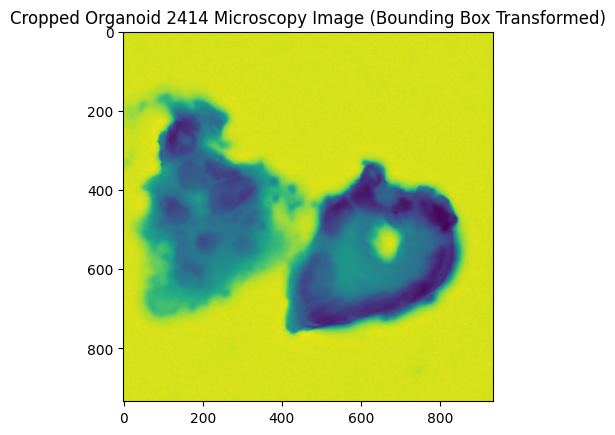

In [23]:
img = np.mean(microscopy[:, int(min_y_histo):int(max_y_histo), int(min_x_histo):int(max_x_histo)], axis=0)
plt.figure()
plt.title("Cropped Organoid 2414 Microscopy Image (Bounding Box Transformed)")
plt.imshow(img)

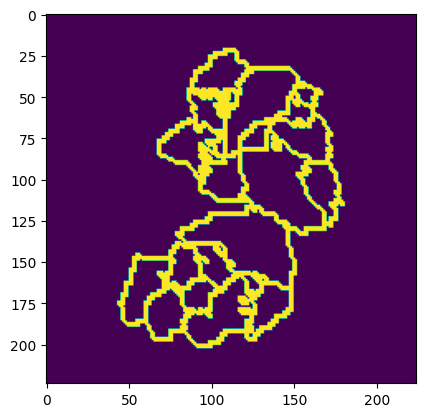

In [24]:
plt.imshow(organoid_masks[2414])

In [31]:
def extract_reoriented_optimized(large_input_image, bbox, transform_matrix, output_size=None):
    """
    Optimized version using cv2.remap on an extracted region.
    """
    min_x, min_y, max_x, max_y = bbox
    
    # Step 1: Find the region of interest in the large image
    corners_original = np.array([
        [min_x, min_y, 1],
        [max_x, min_y, 1],
        [max_x, max_y, 1], 
        [min_x, max_y, 1]
    ]).T
    
    corners_transformed = (transform_matrix @ corners_original).T
    corners_transformed = corners_transformed[:, :2] / corners_transformed[:, 2:]
    
    # Find bounds with padding
    x_min = max(0, int(np.floor(np.min(corners_transformed[:, 0]))))
    y_min = max(0, int(np.floor(np.min(corners_transformed[:, 1]))))
    x_max = min(large_input_image.shape[1], int(np.ceil(np.max(corners_transformed[:, 0]))))
    y_max = min(large_input_image.shape[0], int(np.ceil(np.max(corners_transformed[:, 1]))))

    if output_size is None:
        output_size = (x_max - x_min, y_max - y_min)

    # Extract region
    roi = large_input_image[y_min:y_max, x_min:x_max]
    
    if roi.size == 0:
        return np.zeros((output_size[1], output_size[0], large_input_image.shape[2]), 
                       dtype=large_input_image.dtype)
    
    # Step 2: Create coordinate mapping
    # For each pixel in output, where does it map to in the ROI?
    map_x = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    map_y = np.zeros((output_size[1], output_size[0]), dtype=np.float32)
    
    for y in range(output_size[1]):
        for x in range(output_size[0]):
            # Output pixel → original coordinates
            x_orig = min_x + (x / output_size[0]) * (max_x - min_x)
            y_orig = min_y + (y / output_size[1]) * (max_y - min_y)
            
            # Original coordinates → large image coordinates
            point_orig = np.array([x_orig, y_orig, 1])
            point_img = transform_matrix @ point_orig
            point_img = point_img[:2] / point_img[2]
            
            # Large image coordinates → ROI coordinates
            map_x[y, x] = point_img[0] - x_min
            map_y[y, x] = point_img[1] - y_min
    
    # Step 3: Apply remap to the small ROI
    reoriented = cv2.remap(
        roi,
        map_x,
        map_y,
        interpolation=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )
    
    return (min_x, max_x, min_y, max_y), reoriented

In [33]:
histo_coords, result = extract_reoriented_optimized(np.moveaxis(microscopy, 0, 2), square_bboxes[2414], np.linalg.inv(transform_matrix))
result.shape

(935, 934, 3)

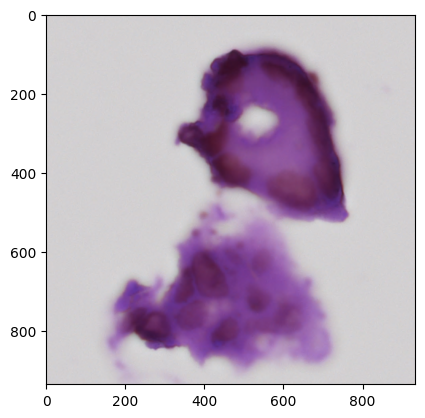

In [34]:
plt.imshow(result)

In [35]:
import cv2
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import numpy as np

def blend_widget(he_image, mask):
    """Short interpolation widget between H&E image and mask."""
    # Resize H&E to match mask
    he_resized = cv2.resize(he_image, (mask.shape[1], mask.shape[0]))
    
    # Ensure mask is binary and uint8
    mask_binary = (mask > 0).astype(np.uint8) 
    mask_rgb = np.stack([mask_binary * 255] * 3, axis=-1)
    
    @interact(alpha=(0.0, 1.0, 0.01))
    def show_blend(alpha=0.5):
        # Convert to float for blending, then back to uint8
        blended = (alpha * mask_rgb.astype(float) + (1 - alpha) * he_resized.astype(float))
        blended = np.clip(blended, 0, 255).astype(np.uint8)  # Ensure valid range
        
        plt.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
        plt.title(f'Alpha: {alpha:.2f}')
        plt.axis('off')
        plt.show()

# Even shorter one-liner style
def quick_blend(he, mask):
    """Ultra-short version."""
    he = cv2.resize(he, (mask.shape[1], mask.shape[0]))
    mask_rgb = np.stack([((mask > 0).astype(np.uint8)) * 255] * 3, axis=-1)
    
    interact(lambda a=0.5: plt.imshow(cv2.cvtColor(
        cv2.addWeighted(he, 1-a, mask_rgb, a, 0), cv2.COLOR_BGR2RGB)) or plt.show())

In [36]:
print(result[..., 0].shape)
print(organoid_masks[2414].shape)
blend_widget(result, organoid_masks[2414])


(935, 934)
(224, 224)


interactive(children=(FloatSlider(value=0.5, description='alpha', max=1.0, step=0.01), Output()), _dom_classes…

# 3. Generation of Organoid H&E Crops as .ome.tiff pyramidal




# 4. TRIDENT Representation Generation
## 4a. Settings

# 4b. Generation

# 5. Patch Analysis
## 5a.Pooling
## 5b. UMAP 